[2026-07-09 21:48:53] [info     ] 计算因子，测试区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-09 21:49:12] [info     ] 开始构建训练集                        train_end='2023-12-31 23:59:59' train_start='2022-01-01 00:00:00'
[2026-07-09 21:49:12] [info     ] build_features 开始              end='2023-12-31 23:59:59' start='2022-01-01 00:00:00'
[2026-07-09 21:49:41] [info     ] 财务原始字段查询完成                     elapsed=29.39 rows=2207410
[2026-07-09 22:02:30] [info     ] 量价原始字段查询完成                     elapsed=769.09 rows=1129170
[2026-07-09 22:04:05] [info     ] 滚动特征计算完成                       cols_added=15 elapsed=94.3
[2026-07-09 22:04:09] [info     ] 标签中间计算完成                       elapsed=4.7
[2026-07-09 22:05:23] [info     ] 截面特征计算完成                       cols_added=8 elapsed=52.82
[2026-07-09 22:05:46] [info     ] BARRA暴露合并完成                    elapsed=23.28 exp_cols=46
[2026-07-09 22:06:08] [info     ] 日行情合并完成                        elapsed=21.8 new_cols=5
[2026-07-09 22:08:10] [info     ] 缺失值处

时段,IC
2024-01-15~2024-02-08,0.0077
2024-09-24~2024-10-08,-0.0012

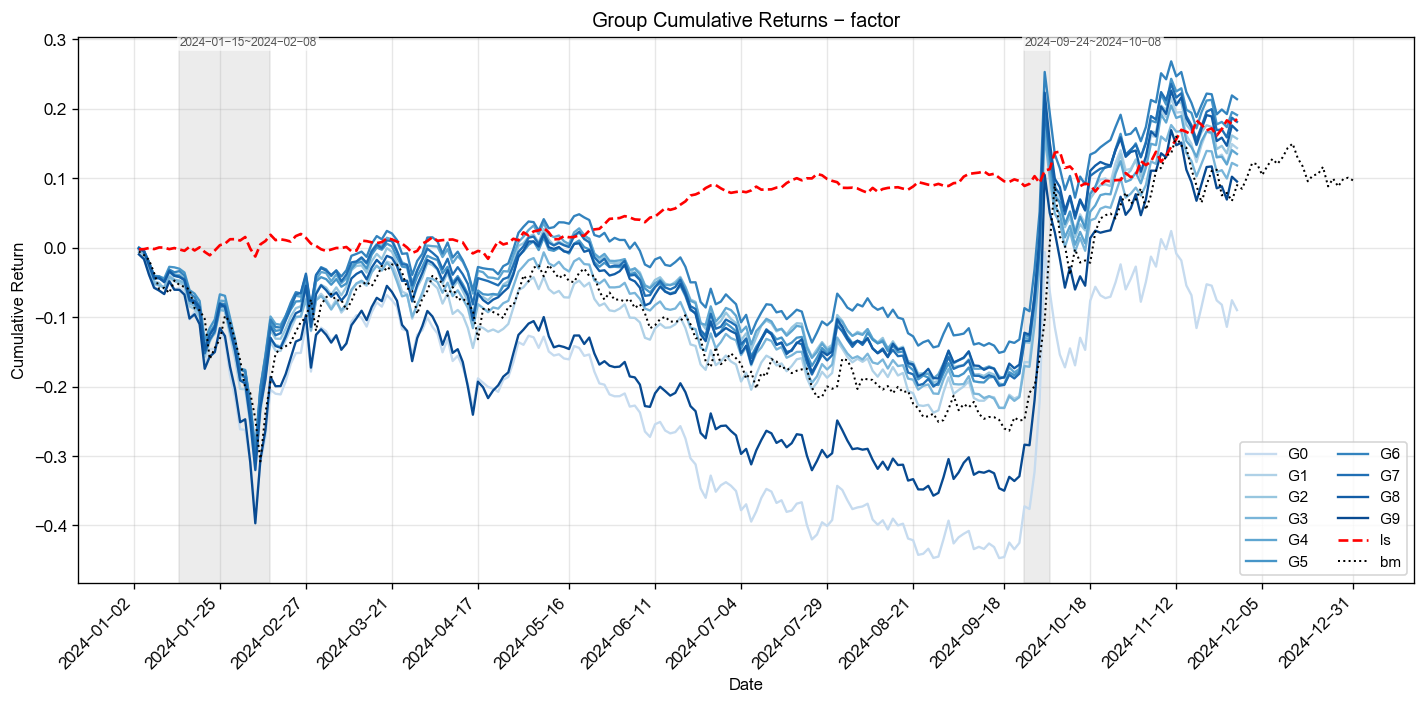
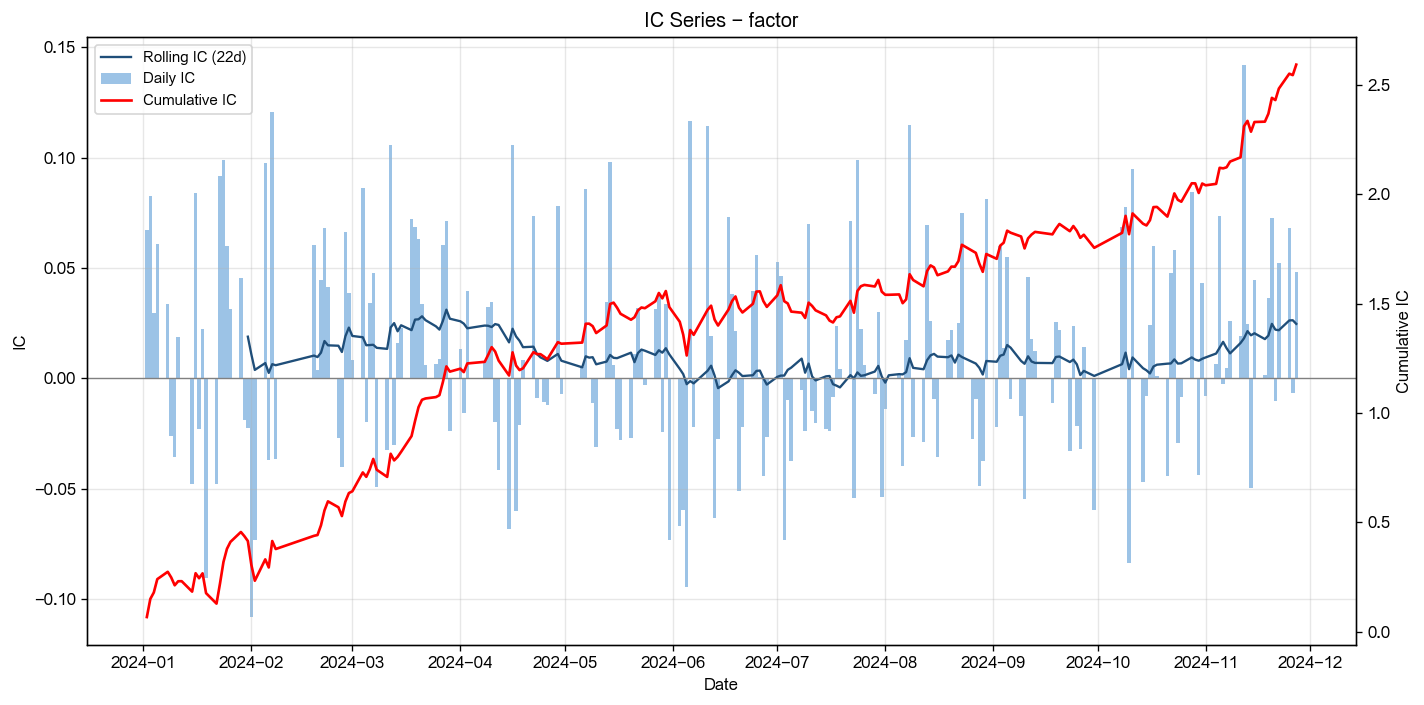
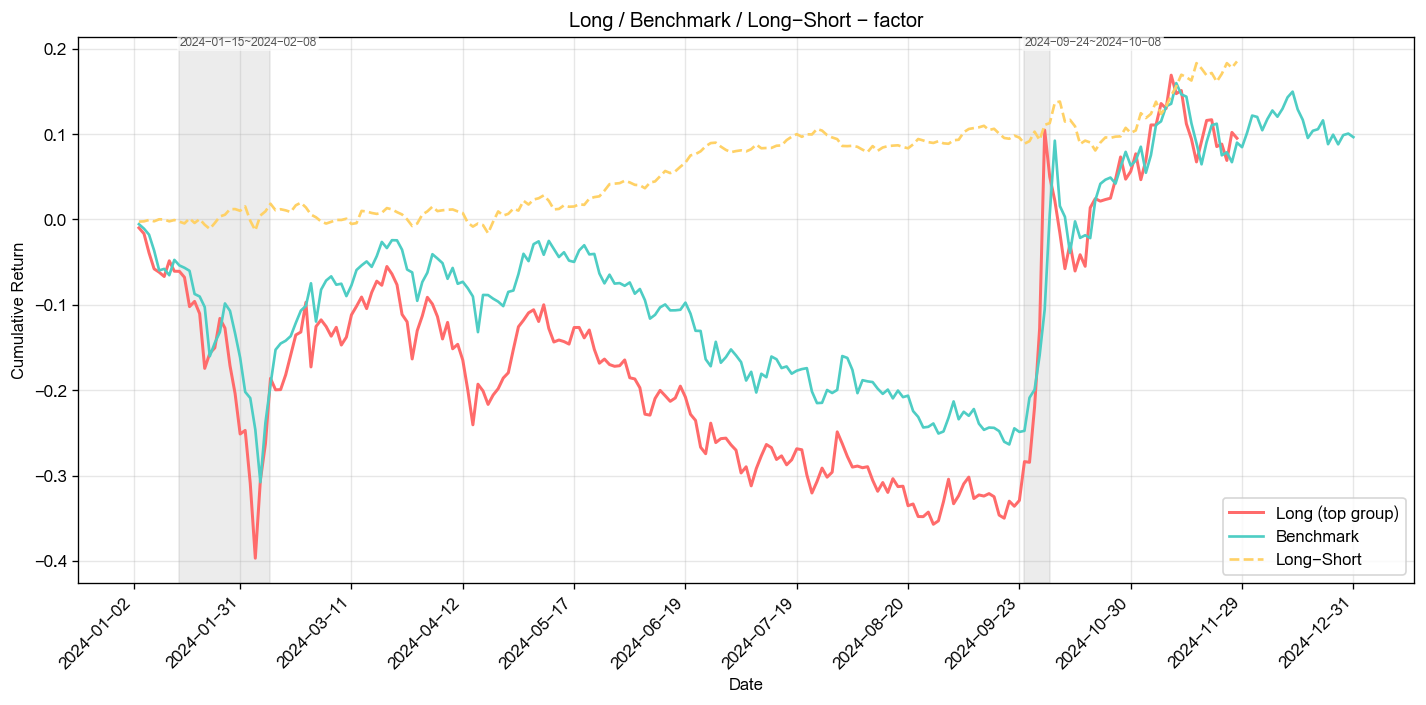
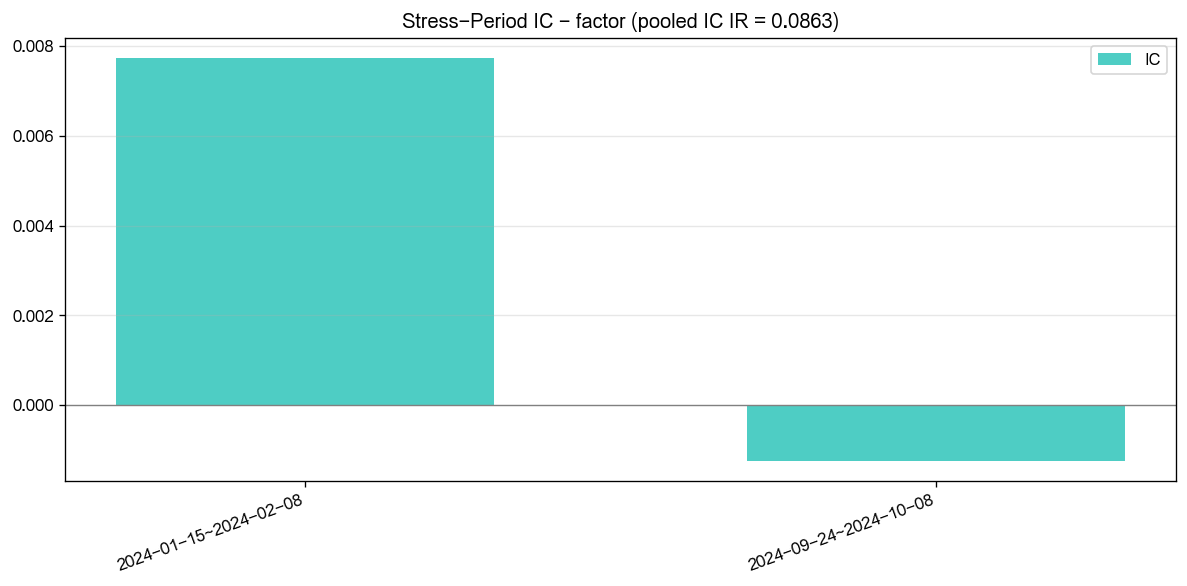
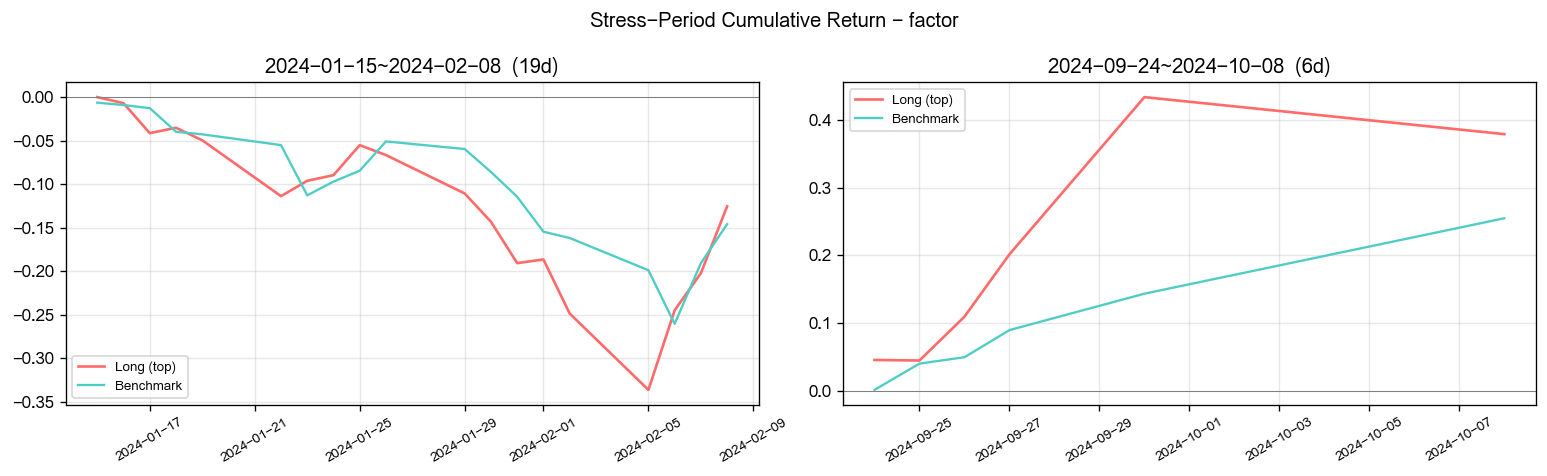

[2026-07-09 23:15:55] [info     ] ========== 因子池回归 ==========
[2026-07-09 23:15:56] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-09 23:15:56] [info     ] 获取收益率数据, 耗时: 0.9907 秒
[2026-07-09 23:15:58] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.3793 秒
[2026-07-09 23:15:58] [info     ] 统计 回归结果, 耗时: 0.0127 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9012,0.0450,0.0237,1.0000
2,amount,1.6552,0.0172,0.0104,0.9000
3,factor,1.5901,0.0120,0.0076,1.0000
4,netflow_amount_rate_main,1.5566,0.0101,0.0065,1.0000
5,netflow_amount_main,1.5171,0.0251,0.0165,1.0000
6,gross_profit_rate_ttm,1.4697,0.0068,0.0046,1.0000
7,cci_14,1.4466,0.0342,0.0237,1.0000
8,net_profit_rate_ttm,1.4457,0.0043,0.0030,0.8000
9,pb,1.3956,0.0096,0.0069,1.0000
10,volume,1.3315,0.0139,0.0105,1.0000

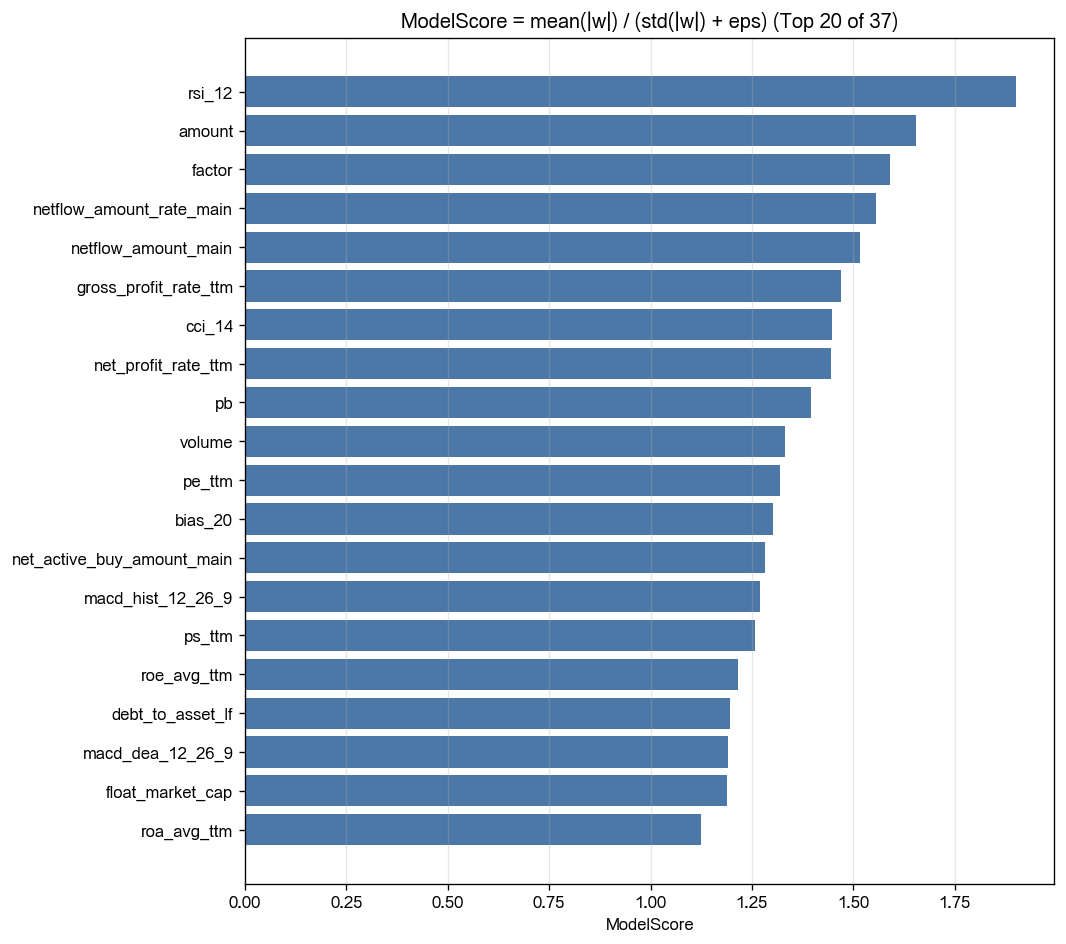
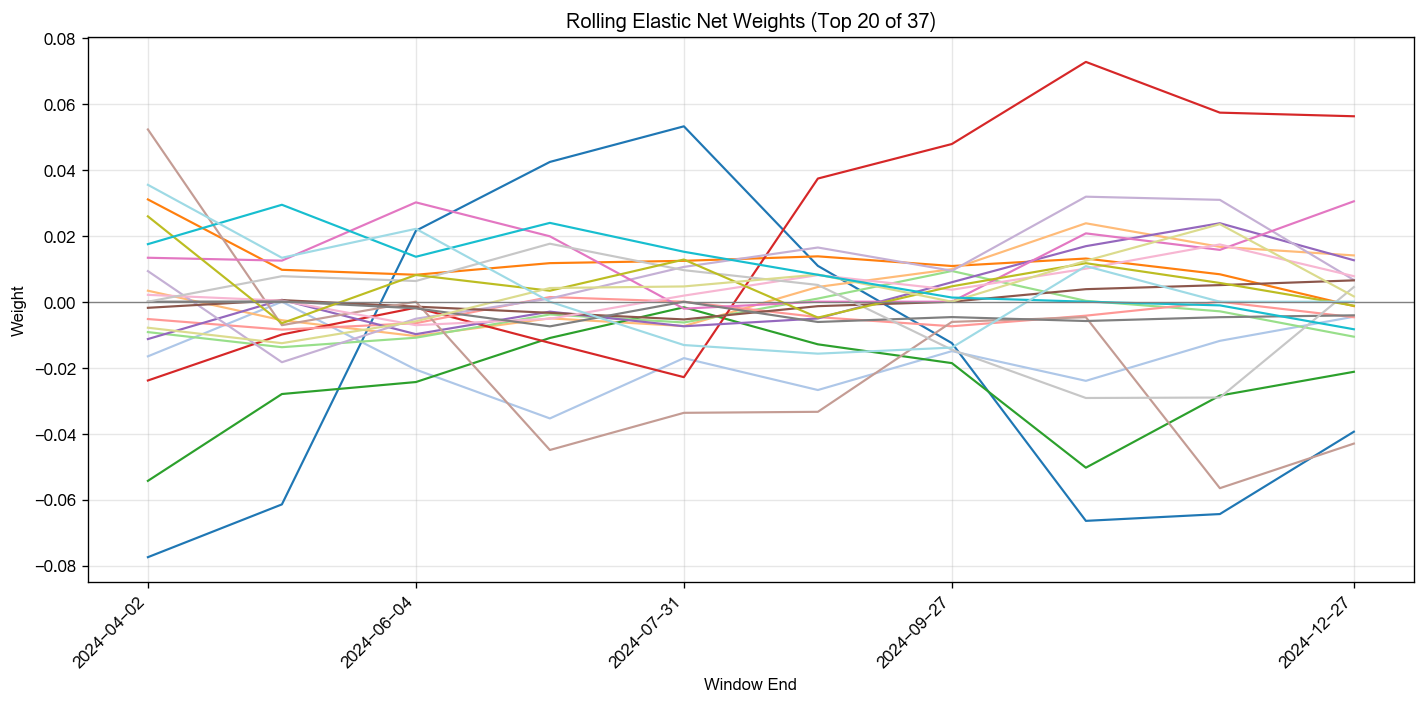
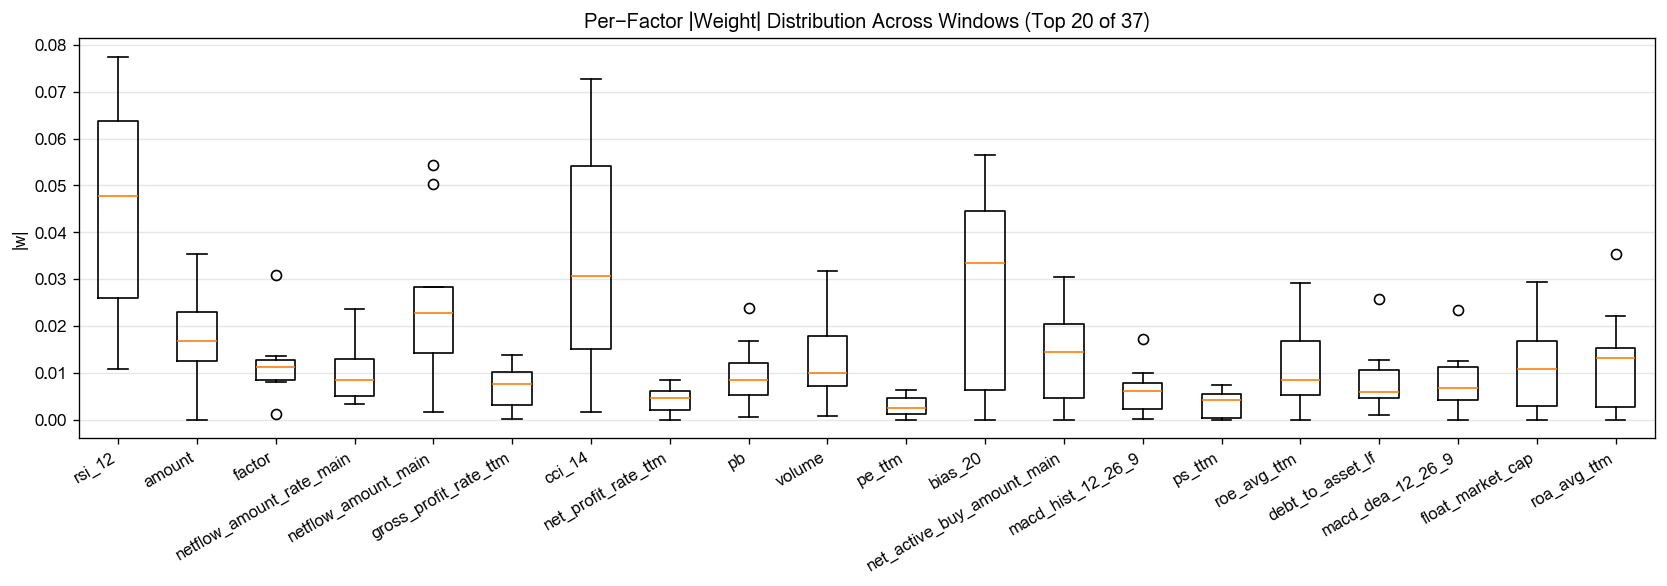
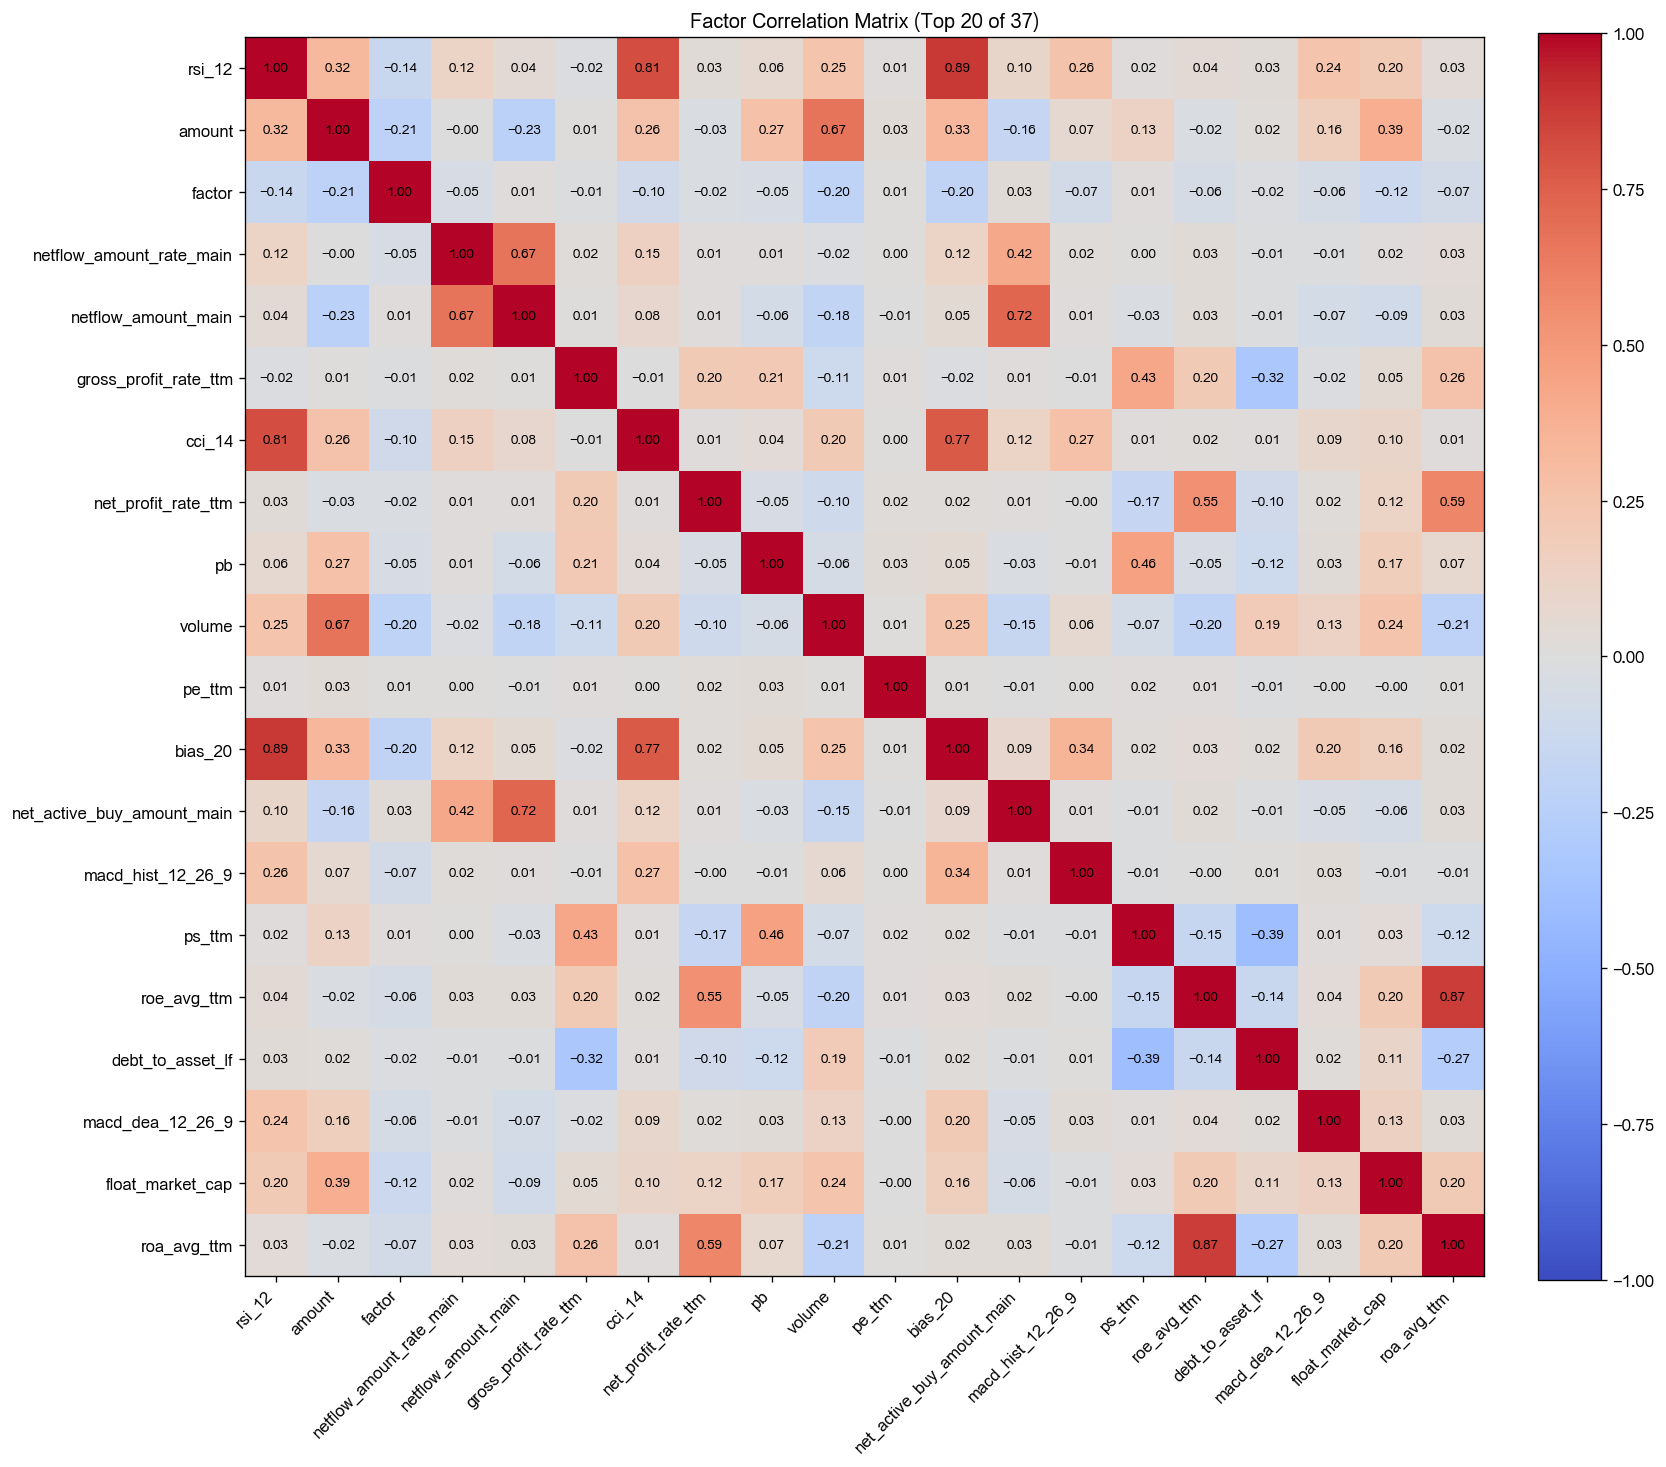

[2026-07-09 23:16:01] [warning  ] 返回的Outputs实例(size=35325198) 大于 64K, 将不会被缓存
[2026-07-09 23:16:01] [info     ] bigalpha_eval.v4 运行完成 [49.255s].


In [1]:
def main(datasources, start_date, end_date):
    import time
    import numpy as np
    import pandas as pd
    import dai
    import xgboost as xgb
    import structlog
    from sklearn.model_selection import train_test_split
    from sklearn.linear_model import LinearRegression

    try:
        import lightgbm as lgb
        HAS_LGB = True
    except ImportError:
        HAS_LGB = False

    logger = structlog.get_logger()

    TRAIN_START = '2022-01-01 00:00:00'
    TRAIN_END   = '2023-12-31 23:59:59'

    price_cols = ['open', 'high', 'low', 'close', 'volume', 'amount',
                  'intraday_vol', 'intraday_return', 'close_position', 'buy_pressure',
                  'ret_5d', 'trade_count', 'spread', 'depth_imbalance', 'open_gap',
                  'mid_price_premium', 'turnover_intensity', 'order_size_imbalance',
                  'return_efficiency']

    fin_cols = ['operating_revenue', 'net_profit_to_parent_shareholders',
                'total_assets', 'total_equity_to_parent_shareholders']

    rolling_cols = [
        'ret_10d', 'ret_20d', 'ret_60d',
        'volatility_5d', 'volatility_10d', 'volatility_20d',
        'volume_ma_5d', 'volume_ma_10d', 'volume_ma_20d',
        'amplitude_ma_5d', 'amplitude_ma_10d', 'amplitude_ma_20d',
        'max_dd_5d', 'max_dd_10d', 'max_dd_20d',
    ]

    cs_cols = [
        'close_rank', 'volume_rank', 'intraday_vol_rank',
        'buy_pressure_rank', 'spread_rank',
        'close_zscore', 'volume_zscore', 'intraday_vol_zscore',
    ]

    extra_label_cols = ['label_multi']

    feature_cols = price_cols + fin_cols + ['roe', 'asset_liability_ratio']


    def build_features(financial_table, bar1m_table, sd, ed):
        t0 = time.time()
        logger.info("build_features 开始", start=str(sd), end=str(ed))

        # —— 步骤A：财务数据 + 前向填充（向量化版本）——
        fin_start = pd.to_datetime(sd) - pd.Timedelta(days=365)
        fin_select = ', '.join(fin_cols)
        fin_sql = f"""
        SELECT date, instrument, {fin_select}
        FROM {financial_table}
        WHERE category='lf' AND shift=0
        """
        fin = dai.query(fin_sql, filters={'date': [fin_start, ed]}).df()

        def fill_natural_dates(df, start_d, end_d):
            natural_dates = pd.date_range(start=start_d, end=end_d)
            df = df.copy()
            df['date'] = pd.to_datetime(df['date'])
            instruments = df['instrument'].unique()
            full_idx = pd.MultiIndex.from_product(
                [natural_dates, instruments], names=['date', 'instrument'])
            df = df.set_index(['date', 'instrument'])
            df = df[~df.index.duplicated(keep='first')]
            df = df.reindex(full_idx)
            df = df.groupby('instrument', group_keys=False).ffill()
            df = df.dropna(subset=[fin_cols[0]])
            df = df.reset_index()
            return df

        fin = fill_natural_dates(fin, fin_start, ed)
        fin['date'] = pd.to_datetime(fin['date'])
        logger.info("财务原始字段查询完成", rows=len(fin), elapsed=round(time.time() - t0, 2))

        # —— 步骤B：1分钟K线 → 日线聚合（buffer=70天，足够60日滚动特征）——
        t1 = time.time()
        price_start = pd.to_datetime(sd) - pd.Timedelta(days=70)
        price_sql = f"""
        SELECT
            date_trunc('day', date)::DATE           AS trading_day,
            instrument,
            ARG_MIN(open, date)                     AS open,
            MAX(high)                               AS high,
            MIN(low)                                AS low,
            ARG_MAX(close, date)                    AS close,
            SUM(volume)                             AS volume,
            SUM(amount)                             AS amount,
            (MAX(high) - MIN(low)) / (ARG_MIN(open, date) + 0.0001)    AS intraday_vol,
            ARG_MAX(close, date) / (ARG_MIN(open, date) + 0.0001) - 1  AS intraday_return,
            (ARG_MAX(close, date) - MIN(low)) / (MAX(high) - MIN(low) + 0.0001) AS close_position,
            SUM(bid_volume1 + bid_volume2 + bid_volume3 + bid_volume4 + bid_volume5) /
                (SUM(bid_volume1 + bid_volume2 + bid_volume3 + bid_volume4 + bid_volume5) +
                 SUM(ask_volume1 + ask_volume2 + ask_volume3 + ask_volume4 + ask_volume5) + 0.0001) AS buy_pressure,
            SUM(deal_number)                        AS trade_count,
            SUM(deal_number) / (SUM(volume) + 0.0001)                    AS turnover_intensity,
            (SUM(bid_volume1) / (SUM(bid_num_orders1) + 0.0001)) /
                (SUM(ask_volume1) / (SUM(ask_num_orders1) + 0.0001) + 0.0001) AS order_size_imbalance,
            AVG((ask_price1 - bid_price1) / (close + 0.0001))          AS spread,
            (SUM(bid_volume1) + SUM(bid_volume2) + SUM(bid_volume3) + SUM(bid_volume4) + SUM(bid_volume5)) /
                (SUM(bid_volume1) + SUM(bid_volume2) + SUM(bid_volume3) + SUM(bid_volume4) + SUM(bid_volume5) +
                 SUM(ask_volume1) + SUM(ask_volume2) + SUM(ask_volume3) + SUM(ask_volume4) + SUM(ask_volume5) + 0.0001) AS depth_imbalance,
            (ARG_MIN(open, date) - ARG_MIN(pre_close, date)) / (ARG_MIN(pre_close, date) + 0.0001) AS open_gap,
            (SUM(bid_price1 * bid_volume1 + bid_price2 * bid_volume2 + bid_price3 * bid_volume3 + bid_price4 * bid_volume4 + bid_price5 * bid_volume5) /
                (SUM(bid_volume1 + bid_volume2 + bid_volume3 + bid_volume4 + bid_volume5) + 0.0001) +
             SUM(ask_price1 * ask_volume1 + ask_price2 * ask_volume2 + ask_price3 * ask_volume3 + ask_price4 * ask_volume4 + ask_price5 * ask_volume5) /
                (SUM(ask_volume1 + ask_volume2 + ask_volume3 + ask_volume4 + ask_volume5) + 0.0001)) / 2 / (AVG(close) + 0.0001) - 1 AS mid_price_premium
        FROM {bar1m_table}
        GROUP BY trading_day, instrument
        ORDER BY trading_day, instrument
        """
        price = dai.query(price_sql, filters={'date': [price_start, ed]}).df().rename(columns={'trading_day': 'date'})
        price['date'] = pd.to_datetime(price['date'])
        price = price.sort_values(['instrument', 'date']).reset_index(drop=True)
        logger.info("量价原始字段查询完成", rows=len(price), elapsed=round(time.time() - t1, 2))

        # —— 步骤B2：滚动特征（向量化 groupby().rolling()，无 Python lambda 开销）——
        t_roll = time.time()
        for col in rolling_cols:
            if col not in feature_cols:
                feature_cols.append(col)

        # 使用 groupby().rolling() 代替 transform(lambda) —— 前者在 C 层计算，快 10-50x
        price['_daily_ret'] = price.groupby('instrument')['close'].pct_change()
        gb = price.groupby('instrument')

        for w, tag in [(10, '10d'), (20, '20d'), (60, '60d')]:
            price[f'ret_{tag}'] = (
                gb['_daily_ret'].rolling(w, min_periods=1).sum()
                .reset_index(level=0, drop=True))

        for w, tag in [(5, '5d'), (10, '10d'), (20, '20d')]:
            price[f'volatility_{tag}'] = (
                gb['_daily_ret'].rolling(w, min_periods=1).std()
                .reset_index(level=0, drop=True))
            price[f'volume_ma_{tag}'] = (
                gb['volume'].rolling(w, min_periods=1).mean()
                .reset_index(level=0, drop=True))
            price[f'amplitude_ma_{tag}'] = (
                gb['intraday_vol'].rolling(w, min_periods=1).mean()
                .reset_index(level=0, drop=True))
            price[f'max_dd_{tag}'] = (
                price['close'] / gb['close'].rolling(w, min_periods=1).max()
                .reset_index(level=0, drop=True) - 1)

        price.drop(columns=['_daily_ret'], inplace=True, errors='ignore')
        logger.info("滚动特征计算完成", cols_added=len(rolling_cols),
                    elapsed=round(time.time() - t_roll, 2))

        # —— 步骤C：标签构造 ——
        t2 = time.time()
        g_close = price.groupby('instrument')['close']
        price['ret_5d'] = g_close.pct_change(5)
        price['label'] = g_close.shift(-1) / price['close'] - 1
        price['_fwd_2d'] = g_close.shift(-2) / price['close'] - 1
        price['_fwd_5d'] = g_close.shift(-5) / price['close'] - 1
        logger.info("标签中间计算完成", elapsed=round(time.time() - t2, 2))

        # —— 步骤D：合并量价 + 财务 + 衍生特征 ——
        df = pd.merge(price, fin, how='inner', on=['date', 'instrument'])

        eps = 1e-8
        df['roe'] = df['net_profit_to_parent_shareholders'] / (df['total_equity_to_parent_shareholders'] + eps)
        df['asset_liability_ratio'] = (df['total_assets'] - df['total_equity_to_parent_shareholders']) / (df['total_assets'] + eps)
        df['return_efficiency'] = df['intraday_return'] / (df['intraday_vol'] + eps)
        df['label_multi'] = df[['label', '_fwd_2d', '_fwd_5d']].mean(axis=1)
        df.drop(columns=['_fwd_2d', '_fwd_5d'], inplace=True, errors='ignore')

        # —— 步骤D2：截面特征 ——
        t_cs = time.time()
        for col in cs_cols:
            if col not in feature_cols:
                feature_cols.append(col)

        _cs_src_cols = {'close', 'volume', 'intraday_vol', 'buy_pressure', 'spread'}
        for _c in _cs_src_cols:
            if _c in df.columns:
                df[_c] = pd.to_numeric(df[_c], errors='coerce')

        rank_map = {
            'close_rank': 'close', 'volume_rank': 'volume',
            'intraday_vol_rank': 'intraday_vol',
            'buy_pressure_rank': 'buy_pressure', 'spread_rank': 'spread',
        }
        for target, src in rank_map.items():
            df[target] = df.groupby('date')[src].rank(pct=True)

        # z-score: 预取 groupby 对象，减少重复构建开销
        gb_date = df.groupby('date')
        for src in ['close', 'volume', 'intraday_vol']:
            target = f'{src}_zscore'
            df[target] = (df[src] - gb_date[src].transform('mean')) / (gb_date[src].transform('std') + eps)

        logger.info("截面特征计算完成", cols_added=len(cs_cols),
                    elapsed=round(time.time() - t_cs, 2))

        # —— 步骤D3：BARRA 风险暴露 ——
        t_exp = time.time()
        exposure = dai.query(
            "SELECT * FROM bigalpha_2026_exposure",
            filters={'date': [sd, ed]},
        ).df()
        exposure['date'] = pd.to_datetime(exposure['date'])
        exposure['instrument'] = exposure['instrument'].astype(str)
        exposure_value_cols = [c for c in exposure.columns if c not in ('date', 'instrument')]
        df = pd.merge(df, exposure, how='left', on=['date', 'instrument'])
        for c in exposure_value_cols:
            if c not in feature_cols:
                feature_cols.append(c)
        logger.info("BARRA暴露合并完成", exp_cols=len(exposure_value_cols),
                    elapsed=round(time.time() - t_exp, 2))

        # —— 步骤D4：日频行情 ——
        t_1d = time.time()
        bar1d = dai.query(
            "SELECT * FROM bigalpha_2026_bar1d",
            filters={'date': [sd, ed]},
        ).df()
        bar1d['date'] = pd.to_datetime(bar1d['date'])
        bar1d['instrument'] = bar1d['instrument'].astype(str)
        bar1d_new_cols = [c for c in bar1d.columns
                          if c not in ('date', 'instrument') and c not in df.columns]
        if bar1d_new_cols:
            df = pd.merge(df, bar1d[['date', 'instrument'] + bar1d_new_cols],
                         how='left', on=['date', 'instrument'])
            for c in bar1d_new_cols:
                if c not in feature_cols:
                    feature_cols.append(c)
        logger.info("日行情合并完成", new_cols=len(bar1d_new_cols),
                    elapsed=round(time.time() - t_1d, 2))

        # —— 步骤E：数据清洗（向量化 —— 一次性转换所有数值列）——
        t3 = time.time()
        cols_to_clean = [c for c in feature_cols if c in df.columns]
        df[cols_to_clean] = df[cols_to_clean].apply(pd.to_numeric, errors='coerce')
        df[cols_to_clean] = df[cols_to_clean].replace([np.inf, -np.inf], np.nan)
        logger.info("缺失值处理完成", elapsed=round(time.time() - t3, 2))

        # —— 步骤F：裁剪到目标区间 ——
        df = df[(df['date'] >= pd.to_datetime(sd)) & (df['date'] <= pd.to_datetime(ed))]
        logger.info("build_features 结束", rows=len(df), total_elapsed=round(time.time() - t0, 2))
        return df.reset_index(drop=True)


    # ═══════════════════════════════════════════════════════════════
    #  第1步：训练模型（n_estimators=300，max_depth=4，轻量化）
    # ═══════════════════════════════════════════════════════════════
    logger.info("开始构建训练集", train_start=TRAIN_START, train_end=TRAIN_END)
    train_df = build_features('bigalpha_2026_financial', 'bigalpha_2026_stock_bar1m',
                              TRAIN_START, TRAIN_END)

    train_feature_cols = list(feature_cols)
    LABEL_COL = 'label_multi'

    for lc in ['label', 'label_vol_adj', 'label_rank', 'label_multi']:
        if lc in train_df.columns:
            train_df[lc] = train_df[lc].replace([np.inf, -np.inf], np.nan)
    train_df = train_df.dropna(subset=[LABEL_COL])

    available_features = [c for c in train_feature_cols if c in train_df.columns]
    logger.info("可用特征数", total=len(available_features))

    train_part, val_part = train_test_split(train_df, test_size=0.2, shuffle=False)

    t_fit = time.time()
    logger.info("开始训练模型", train_samples=len(train_part), val_samples=len(val_part))

    # XGBoost —— 300 棵树、深度 4（比 500×5 快 2-3 倍，效果损失很小）
    model_xgb = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.7,
        min_child_weight=10,
        reg_lambda=1.0,
        reg_alpha=0.5,
        tree_method='hist',
        n_jobs=-1,
        random_state=42,
    )
    model_xgb.fit(
        train_part[available_features], train_part[LABEL_COL],
        eval_set=[(val_part[available_features], val_part[LABEL_COL])],
        early_stopping_rounds=30,
        verbose=False,
    )
    logger.info("XGBoost 训练完成", elapsed=round(time.time() - t_fit, 2),
                best_iteration=model_xgb.best_iteration)

    # LightGBM
    if HAS_LGB:
        t_lgb = time.time()
        model_lgb = lgb.LGBMRegressor(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.03,
            subsample=0.7,
            colsample_bytree=0.7,
            min_child_samples=20,
            reg_lambda=1.0,
            reg_alpha=0.5,
            random_state=43,
            n_jobs=-1,
            verbose=-1,
        )
        model_lgb.fit(
            train_part[available_features], train_part[LABEL_COL],
            eval_set=[(val_part[available_features], val_part[LABEL_COL])],
            eval_metric='rmse',
            callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)],
        )
        logger.info("LightGBM 训练完成", elapsed=round(time.time() - t_lgb, 2),
                    best_iteration=model_lgb.best_iteration_)
    else:
        model_lgb = None
        logger.info("LightGBM 不可用，仅使用 XGBoost")


    # ═══════════════════════════════════════════════════════════════
    #  第2步：测试集预测 → 得因子
    # ═══════════════════════════════════════════════════════════════
    logger.info("开始构建测试集并预测")
    bar1m_table = datasources['bar1m']
    financial_table = datasources['financial']
    test_df = build_features(financial_table, bar1m_table, start_date, end_date)

    common_features = [c for c in train_feature_cols if c in test_df.columns]
    test_df['factor_xgb'] = model_xgb.predict(test_df[common_features])

    if model_lgb is not None:
        test_df['factor_lgb'] = model_lgb.predict(test_df[common_features])
        test_df['factor'] = 0.5 * test_df['factor_xgb'] + 0.5 * test_df['factor_lgb']
        logger.info("使用 XGBoost + LightGBM 集成果子")
    else:
        test_df['factor'] = test_df['factor_xgb']


    # ═══════════════════════════════════════════════════════════════
    #  第2.5步：后处理（BARRA 中性化 + EMA 平滑）
    # ═══════════════════════════════════════════════════════════════
    t_post = time.time()

    try:
        exp_neut = dai.query(
            "SELECT * FROM bigalpha_2026_exposure",
            filters={'date': [start_date, end_date]},
        ).df()
        exp_neut['date'] = pd.to_datetime(exp_neut['date'])
        exp_neut['instrument'] = exp_neut['instrument'].astype(str)
        exp_neut_cols = [c for c in exp_neut.columns if c not in ('date', 'instrument')]

        neut_df = pd.merge(test_df[['date', 'instrument', 'factor']], exp_neut,
                          how='left', on=['date', 'instrument'])
        neut_df[exp_neut_cols] = neut_df[exp_neut_cols].fillna(0)

        if len(exp_neut_cols) > 0:
            X_n = neut_df[exp_neut_cols].values
            y_n = neut_df['factor'].values
            valid = ~np.isnan(y_n)
            if valid.sum() > len(exp_neut_cols) + 10:
                lr = LinearRegression()
                lr.fit(X_n[valid], y_n[valid])
                test_df['factor'] = y_n - lr.predict(X_n)
                logger.info("BARRA 中性化完成", exposure_cols=len(exp_neut_cols))
            else:
                logger.info("有效样本不足，跳过中性化")
        else:
            logger.info("无暴露列，跳过中性化")
    except Exception as e:
        logger.info("中性化跳过", reason=str(e))

    test_df = test_df.sort_values(['instrument', 'date'])
    test_df['factor'] = test_df.groupby('instrument')['factor'].transform(
        lambda x: x.ewm(span=3, adjust=False).mean())

    logger.info("后处理完成", elapsed=round(time.time() - t_post, 2))


    # ═══════════════════════════════════════════════════════════════
    #  第3步：过滤中证1000成分股 + 输出
    # ═══════════════════════════════════════════════════════════════
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},
    ).df()
    stk_pool['instrument'] = stk_pool['instrument'].astype(str)

    result = pd.merge(test_df[['date', 'instrument', 'factor']], stk_pool,
                    how='inner', on=['date', 'instrument'])
    result['factor'] = result['factor'].replace([np.inf, -np.inf], np.nan)
    result = result.dropna(subset=['factor']).reset_index(drop=True)[['date', 'instrument', 'factor']]

    logger.info("因子构建完成", rows=len(result))
    return result


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    datasources = {
        'bar1m': 'bigalpha_2026_stock_bar1m',
        'financial': 'bigalpha_2026_financial'
    }
    start_date = '2024-01-01 00:00:00'
    end_date   = '2024-12-31 23:59:59'

    logger.info(f"计算因子，测试区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval.v4(
        factor_data=factor_data,
        factor_pool=factor_pool,
        start_date=start_date,
        end_date=end_date,
        process_pools=False,
        show=True,
    )